<a href="https://colab.research.google.com/github/Lparedes14/msis-assignments/blob/Final_project_ml_plate_detection/ML_Project_Group_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **MNIST alphanumeric number-plate reading application**

Group 8

**Configuration Setup**

In [6]:
!pip -q install tensorflow_datasets

In [7]:
import os, io, glob, math, json, random, time, shutil, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import hashlib, datetime, traceback
from sklearn.model_selection import train_test_split

In [8]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU        :", gpus if gpus else "NONE - go to Runtime > Change runtime type > T4 GPU")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
CFG = dict(
    # data
    n_train_max   = 220_000,   # subsample of EMNIST train (full = 697,932). Lower = faster.
    n_test_max    = 60_000,    # subsample of EMNIST test  (full = 116,323)
    val_fraction  = 0.10,
    img_size      = 28,
    n_classes     = 36,        # 0-9 + A-Z, case-merged

    # training
    batch_size    = 256,
    epochs_mlp    = 6,
    epochs_cnn    = 18,
    epochs_ft     = 6,         # fine-tune epochs for domain adaptation
    lr            = 1e-3,
    lr_ft         = 2e-4,

    # plate simulation
    plate_len     = 7,         # characters per plate
    n_eval_plates = 400,       # synthetic plates used for end-to-end evaluation
)

CHARS = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
IDX2CHAR = {i: c for i, c in enumerate(CHARS)}
CHAR2IDX = {c: i for i, c in enumerate(CHARS)}
assert len(CHARS) == CFG["n_classes"]

# Glyph pairs that are visually ambiguous and therefore expensive in production.
# Many jurisdictions omit I, O, Q from issued plates for exactly this reason.
CONFUSABLE_PAIRS = [("0","O"), ("1","I"), ("5","S"), ("8","B"), ("2","Z"),
                    ("6","G"), ("7","T"), ("4","A"), ("D","O"), ("U","V")]

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(json.dumps(CFG, indent=2))

{
  "n_train_max": 220000,
  "n_test_max": 60000,
  "val_fraction": 0.1,
  "img_size": 28,
  "n_classes": 36,
  "batch_size": 256,
  "epochs_mlp": 6,
  "epochs_cnn": 18,
  "epochs_ft": 6,
  "lr": 0.001,
  "lr_ft": 0.0002,
  "plate_len": 7,
  "n_eval_plates": 400
}


EMNIST loader: local Kaggle CSVs first, network routes as fallback

In [10]:
RAW_CLASSES = 62                      # ByClass: 0-9, A-Z, a-z
EXPECTED_N  = {"train": 697_932, "test": 116_323}

# ---- manual ingest settings ----
CSV_DIR   = "/content"     # where emnist-byclass-{train,test}.csv live
EXACT_IDX = False          # True = read every row so orig_idx are true file line
                           # numbers (slower). False = pre-sample while parsing.

# EMNIST ships column-major, so a transpose is expected. But we do NOT assume every
# route shares that convention - a library could start correcting it upstream. Instead
# the guard decides, and provenance records what it decided.
#   "auto"     -> try transposed and untransposed, keep whichever passes the guard
#   True/False -> pin it (strict mode; the guard still has to pass)
ORIENTATION_MODE   = "auto"
EXPECTED_TRANSPOSE = True  # what we expect; a mismatch warns loudly, never silently

PROVENANCE = {"orientation_verified": False}


# ---------------------------------------------------------------- geometry --
def _ink_profile(imgs):
    """Normalised ink-mass statistics for a stack of glyphs."""
    m = imgs.astype(np.float32).reshape(-1, 28, 28).mean(0)
    m = m / (m.sum() + 1e-9)
    ys, xs = np.mgrid[0:28, 0:28]
    cy, cx = (m * ys).sum(), (m * xs).sum()
    return dict(
        spread_y=float(np.sqrt((m * (ys - cy) ** 2).sum())),
        spread_x=float(np.sqrt((m * (xs - cx) ** 2).sum())),
        top=float(m[:14].sum()),
        bottom=float(m[14:].sum()),
    )


def assert_upright(X, y_raw, margin=1.05, verbose=True):
    """Fail loudly if glyph orientation has regressed.

    Three falsifiable geometric claims. Transposing an image reflects it across
    the main diagonal, which breaks all three at once. Called inside the loader
    so a later refactor cannot bypass it.
    """
    # raw ByClass labels: 0-9 digits, 10-35 uppercase A-Z, 36-61 lowercase
    idx = {"1": 1,
           "T": 10 + (ord("T") - ord("A")),
           "L": 10 + (ord("L") - ord("A"))}

    report, failures = {}, []
    for ch, k in idx.items():
        sel = X[y_raw == k]
        if len(sel) < 30:
            raise AssertionError(
                f"orientation check needs >=30 samples of '{ch}' (class {k}), found {len(sel)}. "
                "Either n_train_max is too small for a reliable check, or the label mapping "
                "is wrong (is this really the ByClass split?).")
        report[ch] = _ink_profile(sel[:1500])
        report[ch]["n"] = int(len(sel))

    # 1) '1' is a tall narrow stroke
    r = report["1"]
    r["aspect"] = r["spread_y"] / max(r["spread_x"], 1e-6)
    if r["aspect"] < 1.25:
        failures.append(f"'1' aspect (vertical/horizontal ink spread) = {r['aspect']:.2f}, expected > 1.25")

    # 2) 'T' carries its bar across the top
    r = report["T"]
    if r["top"] < r["bottom"] * margin:
        failures.append(f"'T' top ink {r['top']:.3f} vs bottom {r['bottom']:.3f} - not top-heavy")

    # 3) 'L' carries its foot along the bottom
    r = report["L"]
    if r["bottom"] < r["top"] * margin:
        failures.append(f"'L' bottom ink {r['bottom']:.3f} vs top {r['top']:.3f} - not bottom-heavy")

    if verbose:
        print("  orientation checks:")
        print(f"    '1' tall-not-wide : aspect {report['1']['aspect']:.2f}  (need > 1.25)")
        print(f"    'T' top-heavy     : {report['T']['top']:.3f} vs {report['T']['bottom']:.3f}")
        print(f"    'L' bottom-heavy  : {report['L']['bottom']:.3f} vs {report['L']['top']:.3f}")

    if failures:
        raise AssertionError(
            "EMNIST ORIENTATION CHECK FAILED - refusing to return data.\n  - "
            + "\n  - ".join(failures)
            + "\n\nAlmost certainly the transpose was removed or applied twice. "
              "EMNIST is stored column-major; images need np.transpose(X, (0, 2, 1, 3)) "
              "exactly once. See ORIENTATION_MODE in this cell.")
    return report


def _finalise(X, y, max_items, mode=None):
    """Canonicalise, subsample, then let the guard pick the orientation."""
    mode = ORIENTATION_MODE if mode is None else mode
    X = to_canonical_uint8(X)          # resize + grayscale + uint8, one definition
    y = np.asarray(y, np.int32).ravel()
    assert len(X) == len(y), f"length mismatch {len(X)} vs {len(y)}"
    assert y.min() >= 0 and y.max() < RAW_CLASSES, f"labels outside 0-{RAW_CLASSES-1}"

    # Original positions within the source split. Kept so splits can be proven
    # disjoint by index later - without these there is nothing to check.
    orig_idx = np.arange(len(X), dtype=np.int64)

    if max_items and len(X) > max_items:
        # Stratified subsample: a plain rng.choice only matches class proportions
        # in expectation, which is not what "preserving class proportions" means.
        keep, _ = train_test_split(orig_idx, train_size=max_items,
                                   stratify=y, random_state=SEED)
        keep = np.sort(keep)
        X, y, orig_idx = X[keep], y[keep], orig_idx[keep]
        subsample = "stratified"
    else:
        subsample = "none (full split)"

    candidates = [True, False] if mode == "auto" else [bool(mode)]
    failures = {}
    for t in candidates:
        Xc = np.transpose(X, (0, 2, 1, 3)) if t else X
        try:
            report = assert_upright(Xc, y, verbose=False)
        except AssertionError as e:
            failures[t] = str(e).split("\n")[1:4]
            continue
        if t != EXPECTED_TRANSPOSE:
            print(f"  !! WARNING: this route needed transpose={t}, expected "
                  f"{EXPECTED_TRANSPOSE}. The source's layout convention has changed. "
                  f"Recorded in provenance - explain it in the report.")
        return Xc, y, orig_idx, dict(transpose_applied=t, orientation_mode=mode,
                                     subsample=subsample, orientation_report=report)

    raise AssertionError(
        "EMNIST ORIENTATION CHECK FAILED - refusing to return data.\n"
        f"Tried transpose={candidates} and no option produced upright glyphs.\n"
        + json.dumps(failures, indent=2, default=str) +
        "\n\nThis is not a transpose bug - both orientations failed, so the data itself "
        "is wrong. Check the label mapping (ByClass must be 0-9, A-Z, a-z in that order) "
        "and that you loaded emnist-BYCLASS, not balanced/letters/digits.")


# ------------------------------------------------- route 1/3: local CSV -----
def _find_emnist_csv(split):
    """Locate emnist-byclass-{split}.csv, listing what IS present if it is not."""
    names = [f"emnist-byclass-{split}.csv", f"emnist-byclass-{split}.CSV"]
    roots = [CSV_DIR, "/content", "/content/drive/MyDrive",
             "/root/.cache/kagglehub", "."]
    seen = set()
    for root in roots:
        if root in seen or not os.path.isdir(root):
            continue
        seen.add(root)
        for nm in names:
            hits = (glob.glob(os.path.join(root, nm))
                    + glob.glob(os.path.join(root, "**", nm), recursive=True))
            if hits:
                return hits[0]
    present = sorted(os.path.basename(f) for f in glob.glob(f"{CSV_DIR}/*"))[:15]
    raise FileNotFoundError(
        f"emnist-byclass-{split}.csv not found.\n"
        f"  searched: {sorted(seen)}\n"
        f"  files in {CSV_DIR}: {present or '(empty)'}\n"
        "  need: emnist-byclass-train.csv and emnist-byclass-test.csv\n"
        "  if you uploaded a zip:  !unzip -o /content/archive.zip -d /content")


def _load_kaggle_csv(split, max_items):
    path = _find_emnist_csv(split)
    print(f"  reading {os.path.basename(path)} "
          f"({os.path.getsize(path)/1e6:,.0f} MB) - a few minutes for the train file")

    # Kaggle's files have no header row, but mirrors vary. Probe rather than assume.
    probe = pd.read_csv(path, header=None, nrows=1)
    has_header = not pd.api.types.is_numeric_dtype(probe.iloc[:, 0])
    if has_header:
        print("  header row detected, skipping it")

    # Read as uint8: labels are 0-61 and pixels 0-255, so both fit, and it uses
    # ~8x less memory than pandas' default int64 across 700k x 785 values.
    frac = 1.0 if EXACT_IDX else min(
        1.0, (max_items or EXPECTED_N[split]) / EXPECTED_N[split] * 1.25)

    parts, rows = [], 0
    for chunk in pd.read_csv(path, header=0 if has_header else None,
                             chunksize=100_000, dtype=np.uint8):
        rows += len(chunk)
        parts.append(chunk.sample(frac=frac, random_state=SEED) if frac < 1.0 else chunk)
    df = pd.concat(parts, ignore_index=True)
    print(f"  {rows:,} rows in file -> {len(df):,} parsed")

    if df.shape[1] != 785:
        raise ValueError(
            f"expected 785 columns (1 label + 784 pixels), got {df.shape[1]}. "
            "This is not the byclass CSV.")

    labels = df.iloc[:, 0].to_numpy()
    if labels.max() >= RAW_CLASSES:
        raise ValueError(
            f"labels reach {labels.max()}, expected < {RAW_CLASSES}. "
            "Looks like balanced/letters/digits rather than byclass.")
    if max_items and len(df) < max_items:
        print(f"  !! only {len(df):,} rows available, {max_items:,} requested - using all")

    return (df.iloc[:, 1:].to_numpy(), labels,
            dict(library=f"pandas {pd.__version__}",
                 uri=f"local CSV (kaggle:crawford/emnist) -> {path}",
                 prefiltered=bool(frac < 1.0)))


# ---------------------------------------------- route 2/3: torchvision ------
def _load_torchvision(split, max_items):
    import torchvision
    from torchvision import datasets
    ds = datasets.EMNIST(root="./emnist_data", split="byclass",
                         train=(split == "train"), download=True)
    return ds.data.numpy(), ds.targets.numpy(), dict(
        library=f"torchvision {torchvision.__version__}",
        uri="https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip (via torchvision)")


# ----------------------------------------------------- route 3/3: TFDS ------
def _load_tfds(split, max_items):
    import tensorflow_datasets as tfds
    ds, info = tfds.load("emnist/byclass", split=split, as_supervised=True,
                         with_info=True, shuffle_files=True)
    ds = ds.shuffle(100_000, seed=SEED, reshuffle_each_iteration=False)
    if max_items:
        ds = ds.take(int(max_items * 1.05))
    xs, ys = [], []
    for xb, yb in tfds.as_numpy(ds.batch(8192)):
        xs.append(xb); ys.append(yb)
    return np.concatenate(xs), np.concatenate(ys), dict(
        library=f"tensorflow_datasets {tfds.__version__}",
        uri=f"tfds:emnist/byclass:{info.version}")


# --------------------------------------------------------------- driver -----
# Local CSVs first (no network, fully reproducible for a demo), then the
# download routes so the notebook still runs on a machine without the files.
ROUTES = [("kaggle_csv",  _load_kaggle_csv),
          ("torchvision", _load_torchvision),
          ("tfds",        _load_tfds)]


def load_emnist(split, max_items=None, prefer=None):
    order = prefer or [r[0] for r in ROUTES]
    attempts = []
    for name in order:
        fn = dict(ROUTES)[name]
        print(f"[{split}] trying route: {name} ...")
        try:
            t0 = time.time()
            Xr, yr, detail = fn(split, max_items)
            X, y, oidx, ometa = _finalise(Xr, yr, max_items)
            secs = time.time() - t0
            print(f"  OK  {len(X):,} images from '{name}' in {secs:.1f}s")
            PROVENANCE[split] = dict(
                route=name, **detail, n_loaded=int(len(X)),
                raw_classes=RAW_CLASSES, **ometa,
                seconds=round(secs, 1), attempts_before_success=attempts,
                sha256_first_2k=hashlib.sha256(X[:2000].tobytes()).hexdigest()[:16],
                sha256_orig_idx=hashlib.sha256(oidx.tobytes()).hexdigest()[:16],
                loaded_at_utc=datetime.datetime.utcnow().isoformat(timespec="seconds"),
            )
            return X, y, oidx
        except AssertionError:
            raise                     # orientation failure is never a fallback case
        except Exception as e:
            msg = f"{type(e).__name__}: {str(e)[:120]}"
            print(f"  FAILED ({msg}) -> next route")
            attempts.append({name: msg})
    raise RuntimeError(
        "All EMNIST routes failed.\n" + json.dumps(attempts, indent=2) +
        "\n\nManual fallback: download emnist-byclass-train.csv and emnist-byclass-test.csv "
        "from kaggle.com/datasets/crawford/emnist and upload them to /content.")


# ------------------------------------------------------- preflight check ----
print("route order:", [r[0] for r in ROUTES])
for _s in ("train", "test"):
    try:
        _p = _find_emnist_csv(_s)
        print(f"  {_s:>5}: {_p}  ({os.path.getsize(_p)/1e6:,.0f} MB)")
    except FileNotFoundError as e:
        print(f"  {_s:>5}: NOT FOUND - will fall through to torchvision/TFDS")
        print("   ", str(e).splitlines()[2])


route order: ['kaggle_csv', 'torchvision', 'tfds']
  train: NOT FOUND - will fall through to torchvision/TFDS
      files in /content: ['sample_data']
   test: NOT FOUND - will fall through to torchvision/TFDS
      files in /content: ['sample_data']


To define the input contract if missing + make the CSV route fail honestly

In [11]:
# --- 1. input contract (needed by _finalise on every route) ------------------
if "to_canonical_uint8" not in globals():
    print("defining input contract (its cell was not run this session)")

    INPUT_SPEC = dict(height=28, width=28, channels=1,
                      dtype="float32", vmin=0.0, vmax=1.0, storage_dtype="uint8")

    def to_canonical_uint8(X):
        X = np.asarray(X)
        if X.ndim == 2 and X.shape[1] == 784: X = X.reshape(-1, 28, 28)
        elif X.ndim == 2:                     X = X[None, ...]
        if X.ndim == 3:                       X = X[..., None]
        if X.ndim != 4:
            raise ValueError(f"cannot interpret shape {X.shape} as images")
        if X.shape[-1] == 3:
            X = (X[..., :3] * np.array([0.299, 0.587, 0.114])).sum(-1, keepdims=True)
        elif X.shape[-1] != 1:
            raise ValueError(f"expected 1 or 3 channels, got {X.shape[-1]}")
        h, w = X.shape[1], X.shape[2]
        if (h, w) != (28, 28):
            print(f"  resizing {h}x{w} -> 28x28")
            interp = cv2.INTER_AREA if (h > 28 or w > 28) else cv2.INTER_CUBIC
            X = np.stack([cv2.resize(im.squeeze().astype(np.uint8), (28, 28),
                                     interpolation=interp) for im in X])[..., None]
        if X.dtype != np.uint8:
            X = np.clip(X, 0, 255).astype(np.uint8)
        assert X.shape[1:] == (28, 28, 1) and X.dtype == np.uint8
        return X

    def normalize(x):
        if isinstance(x, np.ndarray):
            if x.dtype != np.uint8:
                raise TypeError(f"normalize() expects uint8, got {x.dtype}")
            return x.astype(np.float32) / 255.0
        if x.dtype != tf.uint8:
            raise TypeError(f"normalize() expects tf.uint8, got {x.dtype}")
        return tf.cast(x, tf.float32) / 255.0

    def assert_input_contract(x, name="batch"):
        arr = x.numpy() if hasattr(x, "numpy") else np.asarray(x)
        bad = []
        if arr.ndim != 4:                  bad.append(f"ndim {arr.ndim}, expected 4")
        elif arr.shape[1:] != (28, 28, 1): bad.append(f"shape {arr.shape[1:]}")
        if arr.dtype != np.float32:        bad.append(f"dtype {arr.dtype}")
        lo, hi = float(arr.min()), float(arr.max())
        if lo < -1e-6 or hi > 1 + 1e-6:    bad.append(f"range [{lo:.3f},{hi:.3f}]")
        if hi <= 0.02 and arr.size > 100:  bad.append(f"max {hi:.5f} - double-normalised?")
        if bad:
            raise AssertionError(f"INPUT CONTRACT VIOLATED for '{name}': " + "; ".join(bad))
        return dict(name=name, shape=list(arr.shape), dtype=str(arr.dtype),
                    min=round(lo, 5), max=round(hi, 5), mean=round(float(arr.mean()), 5))
else:
    print("input contract already defined")


# --- 2. CSV route: validate row count instead of trusting the file -----------
def _load_kaggle_csv(split, max_items):
    path = _find_emnist_csv(split)
    print(f"  reading {os.path.basename(path)} ({os.path.getsize(path)/1e6:,.0f} MB)")

    probe = pd.read_csv(path, header=None, nrows=1)
    has_header = not pd.api.types.is_numeric_dtype(probe.iloc[:, 0])

    # No dtype coercion here: a truncated final row yields NaN, and forcing uint8
    # turns that into an opaque "Integer column has NA values" error.
    frac = 1.0 if EXACT_IDX else min(
        1.0, (max_items or EXPECTED_N[split]) / EXPECTED_N[split] * 1.25)

    parts, rows = [], 0
    for chunk in pd.read_csv(path, header=0 if has_header else None, chunksize=100_000):
        rows += len(chunk)
        parts.append(chunk.sample(frac=frac, random_state=SEED) if frac < 1.0 else chunk)
    df = pd.concat(parts, ignore_index=True)

    expected = EXPECTED_N[split]
    print(f"  {rows:,} rows read (file should contain {expected:,})")
    if rows < expected * 0.95:
        raise ValueError(
            f"{os.path.basename(path)} has {rows:,} rows but byclass-{split} has "
            f"{expected:,}. The file is truncated or is a different split - the "
            "upload probably did not finish. Re-download and re-upload it.")

    n_na = int(df.isna().any(axis=1).sum())
    if n_na:
        print(f"  !! {n_na} rows contain missing values - dropping them")
        df = df.dropna()

    if df.shape[1] != 785:
        raise ValueError(f"expected 785 columns, got {df.shape[1]}. Not the byclass CSV.")
    labels = df.iloc[:, 0].to_numpy().astype(np.int32)
    if labels.max() >= RAW_CLASSES:
        raise ValueError(f"labels reach {labels.max()}, expected < {RAW_CLASSES}. "
                         "Looks like balanced/letters/digits, not byclass.")

    pixels = df.iloc[:, 1:].to_numpy()
    pixels = np.clip(pixels, 0, 255).astype(np.uint8)
    return pixels, labels, dict(library=f"pandas {pd.__version__}",
                                uri=f"local CSV (kaggle:crawford/emnist) -> {path}",
                                prefiltered=bool(frac < 1.0))

ROUTES = [("kaggle_csv", _load_kaggle_csv),
          ("torchvision", _load_torchvision),
          ("tfds", _load_tfds)]
print("routes ready:", [r[0] for r in ROUTES])

defining input contract (its cell was not run this session)
routes ready: ['kaggle_csv', 'torchvision', 'tfds']


In [12]:
X_tr_full, y_tr_full, idx_tr_full = load_emnist("train", CFG["n_train_max"])
X_te,      y_te,      idx_te      = load_emnist("test",  CFG["n_test_max"])

PROVENANCE["config"] = CFG
PROVENANCE["seed"]   = SEED
with open("provenance.json", "w") as f:
    json.dump(PROVENANCE, f, indent=2, default=str)

print("\n" + "="*66)
print("DATA PROVENANCE  (also written to provenance.json - cite this in the report)")
print("="*66)
for split in ("train", "test"):
    p = PROVENANCE[split]
    print(f"{split:>6}: route={p['route']:<12} n={p['n_loaded']:>7,}  "
          f"transpose={p['transpose_applied']}  hash={p['sha256_first_2k']}")
    print(f"        source: {p['uri']}")
    if p["attempts_before_success"]:
        print(f"        fell back after: {p['attempts_before_success']}")
print("="*66)

[train] trying route: kaggle_csv ...
  FAILED (FileNotFoundError: emnist-byclass-train.csv not found.
  searched: ['.', '/content']
  files in /content: ['sample_data']
  need: emnist-by) -> next route
[train] trying route: torchvision ...


100%|██████████| 562M/562M [00:03<00:00, 147MB/s]


  OK  220,000 images from 'torchvision' in 45.1s
[test] trying route: kaggle_csv ...
  FAILED (FileNotFoundError: emnist-byclass-test.csv not found.
  searched: ['.', '/content']
  files in /content: ['emnist_data', 'sample_data']
  n) -> next route
[test] trying route: torchvision ...
  OK  60,000 images from 'torchvision' in 0.2s

DATA PROVENANCE  (also written to provenance.json - cite this in the report)
 train: route=torchvision  n=220,000  transpose=True  hash=31ad91c785176726
        source: https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip (via torchvision)
        fell back after: [{'kaggle_csv': "FileNotFoundError: emnist-byclass-train.csv not found.\n  searched: ['.', '/content']\n  files in /content: ['sample_data']\n  need: emnist-by"}]
  test: route=torchvision  n= 60,000  transpose=True  hash=74ac3fc25427b3a6
        source: https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip (via torchvision)
        fell back after: [{'kaggle_csv': "FileNotFoundError: emnist-byclas

ACCEPTANCE GATE - ten samples plotted and checked before any training runs

  orientation checks:
    '1' tall-not-wide : aspect 2.07  (need > 1.25)
    'T' top-heavy     : 0.716 vs 0.284
    'L' bottom-heavy  : 0.693 vs 0.307


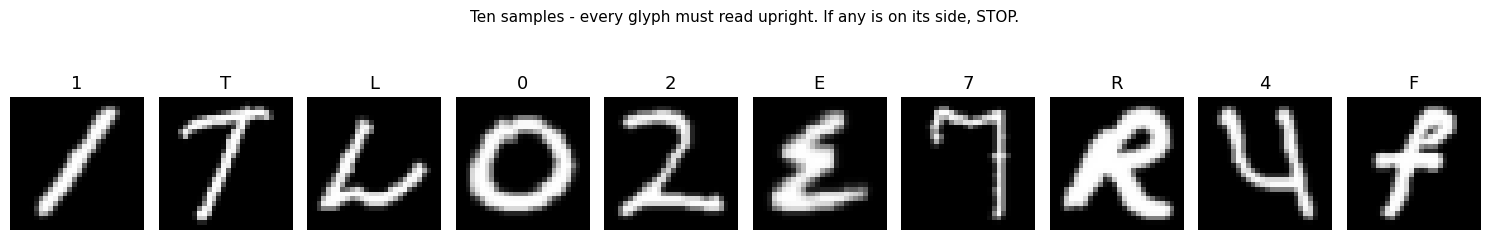

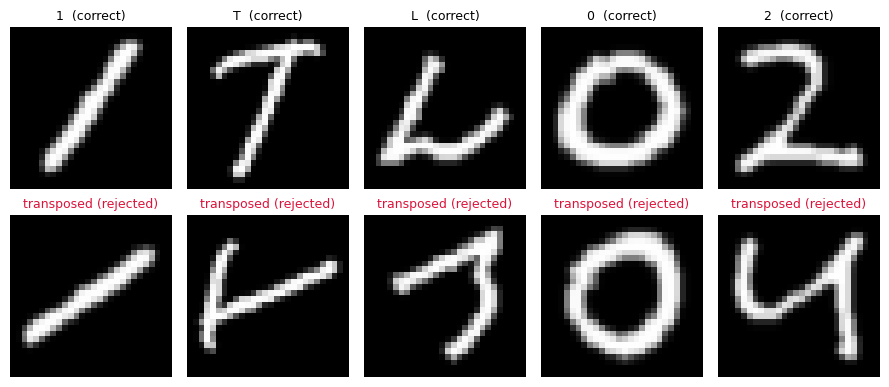


Guard self-test PASSED: transposed input is correctly rejected.
Orientation verified. Training is unlocked.


In [13]:
report = assert_upright(X_tr_full, y_tr_full, verbose=True)   # raises if regressed

RAW_LABEL = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
rng = np.random.default_rng(SEED)
picks = [int(rng.choice(np.where(y_tr_full == k)[0]))
         for k in [1, 10+ord('T')-ord('A'), 10+ord('L')-ord('A'), 0, 2,
                   10+ord('E')-ord('A'), 7, 10+ord('R')-ord('A'), 4,
                   10+ord('F')-ord('A')]]

fig, axes = plt.subplots(1, 10, figsize=(15, 2.1))
for ax, i in zip(axes, picks):
    ax.imshow(X_tr_full[i].squeeze(), cmap="gray")
    ax.set_title(RAW_LABEL[y_tr_full[i]], fontsize=13); ax.axis("off")
plt.suptitle("Ten samples - every glyph must read upright. If any is on its side, STOP.",
             y=1.16, fontsize=11)
plt.tight_layout(); plt.show()

# Side-by-side proof of what the guard is actually catching
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for j, i in enumerate(picks[:5]):
    axes[0, j].imshow(X_tr_full[i].squeeze(), cmap="gray")
    axes[0, j].set_title(f"{RAW_LABEL[y_tr_full[i]]}  (correct)", fontsize=9)
    axes[1, j].imshow(X_tr_full[i].squeeze().T, cmap="gray")
    axes[1, j].set_title("transposed (rejected)", fontsize=9, color="crimson")
    axes[0, j].axis("off"); axes[1, j].axis("off")
plt.tight_layout(); plt.show()

# Prove the guard actually fires - a check that never fails is not a check
try:
    assert_upright(np.transpose(X_tr_full[:20000], (0, 2, 1, 3)),
                   y_tr_full[:20000], verbose=False)
    raise SystemExit("GUARD IS BROKEN: it accepted transposed data. Do not train.")
except AssertionError:
    print("\nGuard self-test PASSED: transposed input is correctly rejected.")

PROVENANCE["orientation_verified"] = True
PROVENANCE["orientation_report"]   = report
with open("provenance.json", "w") as f:
    json.dump(PROVENANCE, f, indent=2, default=str)
print("Orientation verified. Training is unlocked.")


 Threshold calibration - does the guard have enough headroom on THIS data?



In [14]:
def calibrate_guard(X, y, n=1500):
    idx = {"1": 1, "T": 10 + (ord("T")-ord("A")), "L": 10 + (ord("L")-ord("A"))}
    up, tr = {}, {}
    for ch, k in idx.items():
        sel = X[y == k][:n]
        up[ch] = _ink_profile(sel)
        tr[ch] = _ink_profile(np.transpose(sel, (0, 2, 1, 3)))

    tests = [
        ("'1' tall-not-wide", up["1"]["spread_y"]/up["1"]["spread_x"],
                              tr["1"]["spread_y"]/tr["1"]["spread_x"], 1.25),
        ("'T' top-heavy",     up["T"]["top"]/up["T"]["bottom"],
                              tr["T"]["top"]/tr["T"]["bottom"],        1.05),
        ("'L' bottom-heavy",  up["L"]["bottom"]/up["L"]["top"],
                              tr["L"]["bottom"]/tr["L"]["top"],        1.05),
    ]

    rows, weak = [], []
    for name, obs, cf, cur in tests:
        suggested = float(np.sqrt(max(obs, 1e-6) * max(cf, 1e-6)))   # midpoint in log space
        headroom  = obs / cur
        separation = obs / max(cf, 1e-6)
        rows.append(dict(test=name, observed=obs, transposed_counterfactual=cf,
                         current_threshold=cur, suggested_threshold=round(suggested, 3),
                         headroom_x=round(headroom, 2), separation_x=round(separation, 1)))
        if headroom < 1.20 or separation < 1.5:
            weak.append(name)

    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    print()
    if weak:
        print(f"TIGHT: {weak}")
        print("  Observed value sits too close to the threshold or to the transposed case.")
        print("  Raise the margin toward 'suggested_threshold', or swap that glyph for one")
        print("  with a stronger asymmetry (try 'J', 'F' or '7').")
    else:
        print("All three tests clear their thresholds with margin, and separate cleanly")
        print("from the transposed counterfactual. Guard is trustworthy on this data.")
    return df

calib = calibrate_guard(X_tr_full, y_tr_full)
PROVENANCE["guard_calibration"] = calib.to_dict("records")

             test  observed  transposed_counterfactual  current_threshold  suggested_threshold  headroom_x  separation_x
'1' tall-not-wide    2.0705                     0.4830             1.2500               1.0000      1.6600        4.3000
    'T' top-heavy    2.5187                     1.6153             1.0500               2.0170      2.4000        1.6000
 'L' bottom-heavy    2.2621                     0.4973             1.0500               1.0610      2.1500        4.5000

All three tests clear their thresholds with margin, and separate cleanly
from the transposed counterfactual. Guard is trustworthy on this data.


Case merge 62 -> 36, now that orientation is confirmed

In [15]:
assert PROVENANCE["orientation_verified"], "Run the orientation gate cell first."

def merge_case(y):
    y = np.asarray(y)
    if y.max() < CFG["n_classes"]:          # idempotent: re-running this cell is safe
        return y.astype(np.int32)
    return np.where(y >= 36, y - 26, y).astype(np.int32)

y_te_raw = y_te.copy()          # pre-merge, needed by the cross-route check
y_tr_full, y_te = merge_case(y_tr_full), merge_case(y_te)

assert y_tr_full.max() < CFG["n_classes"] and y_te.max() < CFG["n_classes"]
assert set(np.unique(y_tr_full)) == set(range(CFG["n_classes"])), "not all 36 classes present"
print(f"train {X_tr_full.shape} labels {y_tr_full.min()}-{y_tr_full.max()}")
print(f"test  {X_te.shape}")

train (220000, 28, 28, 1) labels 0-35
test  (60000, 28, 28, 1)


Cross-route agreement - do two independent sources agree on label -> glyph?

In [16]:
# The orientation guard verifies geometry. It does not verify that route A and
# route B index their classes identically (torchvision remaps labels for the
# 'letters' split, for instance). This catches that class of bug.

RAW_LABEL = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

def _case_partner(k):
    """Uppercase class for a lowercase one and vice versa. None for digits."""
    if 10 <= k <= 35: return k + 26
    if 36 <= k <= 61: return k - 26
    return None


def cross_route_check(n=6000, exclude=None):
    ref_route = PROVENANCE["test"]["route"]
    others = [r for r, _ in ROUTES if r != ref_route and r != (exclude or "")]
    Xa, ya = X_te[:n], y_te_raw[:n]

    for other in others:
        try:
            print(f"comparing '{ref_route}' against '{other}' ...")
            Xr, yr, _ = dict(ROUTES)[other]("test", n)
            Xb, yb, _, _ = _finalise(Xr, yr, n)
        except AssertionError:
            raise
        except Exception as e:
            print(f"  route unavailable ({type(e).__name__}) - skipped"); continue

        common = [k for k in range(RAW_CLASSES)
                  if (ya == k).sum() >= 15 and (yb == k).sum() >= 15]
        A = np.stack([Xa[ya == k].mean(0).ravel() for k in common])
        B = np.stack([Xb[yb == k].mean(0).ravel() for k in common])
        A = (A - A.mean(1, keepdims=True)) / (A.std(1, keepdims=True) + 1e-9)
        B = (B - B.mean(1, keepdims=True)) / (B.std(1, keepdims=True) + 1e-9)
        C = A @ B.T / A.shape[1]
        diag = float(np.mean(np.diag(C)))
        print(f"  {len(common)} classes compared | mean self-correlation {diag:.3f}")

        # A lowercase glyph matching its own uppercase is the known case-similarity
        # problem, not a reordering bug. Only unrelated matches indicate a mismatch.
        mismatched, case_conf = [], []
        for i in range(len(common)):
            true_k, got_k = common[i], common[int(C[i].argmax())]
            if got_k == true_k:
                continue
            (case_conf if got_k == _case_partner(true_k) else mismatched).append(
                (true_k, got_k))

        if case_conf:
            pairs = ", ".join(f"{RAW_LABEL[a]}/{RAW_LABEL[b]}" for a, b in case_conf)
            print(f"  {len(case_conf)} case-partner confusions (expected): {pairs}")
        if mismatched:
            raise AssertionError(
                f"LABEL MAPPING MISMATCH between '{ref_route}' and '{other}'.\n"
                f"Classes matching an unrelated class: {mismatched[:10]}\n"
                "One source is using a different class ordering. Do not merge them.")

        print(f"  OK - label ordering is identical")
        PROVENANCE.setdefault("cross_route_checks", []).append(
            dict(reference=ref_route, compared=other, n_classes=len(common),
                 mean_self_correlation=round(diag, 4),
                 case_partner_confusions=[f"{RAW_LABEL[a]}/{RAW_LABEL[b]}"
                                          for a, b in case_conf],
                 passed=True))


try:
    cross_route_check()
except NameError:
    print("y_te_raw not defined - the merge cell must save it before merging.")

comparing 'torchvision' against 'kaggle_csv' ...
  route unavailable (FileNotFoundError) - skipped
comparing 'torchvision' against 'tfds' ...


ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

  route unavailable (AttributeError) - skipped


In [17]:
 ACCEPTANCE SIGN-OFF - writes the artefact your report cites

SyntaxError: invalid syntax (596226786.py, line 1)

In [18]:
crit = {
  "1. Ten samples plotted and visually confirmed upright before training": dict(
      automated = PROVENANCE.get("orientation_verified", False),
      manual    = "HUMAN: confirm the ten glyphs above read upright",
      evidence  = "gate cell plots 10 labelled samples; both fit() cells assert the flag"),
  "2. Assertion in the loader that fails loudly on orientation regression": dict(
      automated = "orientation_report" in PROVENANCE,
      manual    = None,
      evidence  = "assert_upright() called inside _finalise(); self-test proves it fires"),
  "3. Load method and source recorded so results reproduce": dict(
      automated = all(k in PROVENANCE.get("train", {})
                      for k in ("route","uri","sha256_first_2k","loaded_at_utc")),
      manual    = None,
      evidence  = "provenance.json"),
}

lines = ["# EMNIST load - acceptance record", "",
         f"Generated {datetime.datetime.utcnow().isoformat(timespec='seconds')}Z", ""]
for name, c in crit.items():
    mark = "PASS" if c["automated"] is True else "FAIL"
    lines.append(f"- **[{mark}]** {name}")
    lines.append(f"  - evidence: {c['evidence']}")
    if c["manual"]:
        lines.append(f"  - [ ] {c['manual']}")

for split in ("train", "test"):
    p = PROVENANCE[split]
    lines += ["", f"## {split} split", "",
              f"- route: `{p['route']}`  (fell back past: {p['attempts_before_success'] or 'none'})",
              f"- source: `{p['uri']}`",
              f"- library: {p['library']}",
              f"- images: {p['n_loaded']:,}   transpose applied: {p['transpose_applied']}",
              f"- content hash (first 2k): `{p['sha256_first_2k']}`",
              f"- loaded: {p['loaded_at_utc']}Z"]

lines += ["", "## Environment", "",
          f"- seed: {SEED}", f"- numpy {np.__version__}, tensorflow {tf.__version__}"]

open("acceptance_record.md", "w").write("\n".join(lines))
with open("provenance.json", "w") as f:
    json.dump(PROVENANCE, f, indent=2, default=str)

print("\n".join(lines))

# --- persist beyond the runtime ---------------------------------------------
PERSIST_TO_DRIVE = False        # set True to copy into Google Drive
if PERSIST_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    dest = "/content/drive/MyDrive/anpr_emnist"; os.makedirs(dest, exist_ok=True)
    for f in ("provenance.json", "acceptance_record.md"):
        shutil.copy(f, dest)
    print(f"\ncopied to {dest}")
else:
    print("\nprovenance.json and acceptance_record.md are in /content and will be LOST")
    print("when the runtime disconnects. Set PERSIST_TO_DRIVE=True or download them:")
    print("  from google.colab import files; files.download('provenance.json')")

# EMNIST load - acceptance record

Generated 2026-08-10T21:33:05Z

- **[PASS]** 1. Ten samples plotted and visually confirmed upright before training
  - evidence: gate cell plots 10 labelled samples; both fit() cells assert the flag
  - [ ] HUMAN: confirm the ten glyphs above read upright
- **[PASS]** 2. Assertion in the loader that fails loudly on orientation regression
  - evidence: assert_upright() called inside _finalise(); self-test proves it fires
- **[PASS]** 3. Load method and source recorded so results reproduce
  - evidence: provenance.json

## train split

- route: `torchvision`  (fell back past: [{'kaggle_csv': "FileNotFoundError: emnist-byclass-train.csv not found.\n  searched: ['.', '/content']\n  files in /content: ['sample_data']\n  need: emnist-by"}])
- source: `https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip (via torchvision)`
- library: torchvision 0.26.0+cu128
- images: 220,000   transpose applied: True
- content hash (first 2k): `31ad91c785176726`
- loaded: 2